In [1]:
import json
from pathlib import Path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from src.utils.plotting import plot_provenance_accuracy

def plot_metrics(path):
    path = Path(path)
    data = json.loads(path.read_text())
    rows = []
    for item in data:
        rows.append({"round": item["round"], "metric": "avg_loss", "value": item["avg_loss"]})
        rows.append({"round": item["round"], "metric": "avg_perplexity", "value": item["avg_perplexity"]})
        for ds, metrics in item["metrics_per_dataset"].items():
            for name, value in metrics.items():
                rows.append({"round": item["round"], "metric": f"dataset{ds}_{name}", "value": value})
    df = pd.DataFrame(rows)
    sns.set_theme(style="whitegrid")
    fig, (ax_loss, ax_perp) = plt.subplots(1, 2, figsize=(10, 5), sharex=True)
    sns.lineplot(df[df.metric.str.contains("loss")], x="round", y="value", hue="metric", marker="o", ax=ax_loss)
    sns.lineplot(df[df.metric.str.contains("perplexity")], x="round", y="value", hue="metric", marker="o", ax=ax_perp)
    ax_loss.set_title("loss")
    ax_perp.set_title("perplexity")
    ax_loss.set_yscale("log")
    ax_perp.set_yscale("log")
    fig.suptitle(path.name)
    plt.tight_layout()
    plt.show()

# plot_metrics('results/fl_train_metrics_[google_gemma-3-1b-pt][rounds17][clients2][C0-chess-C1math].json')

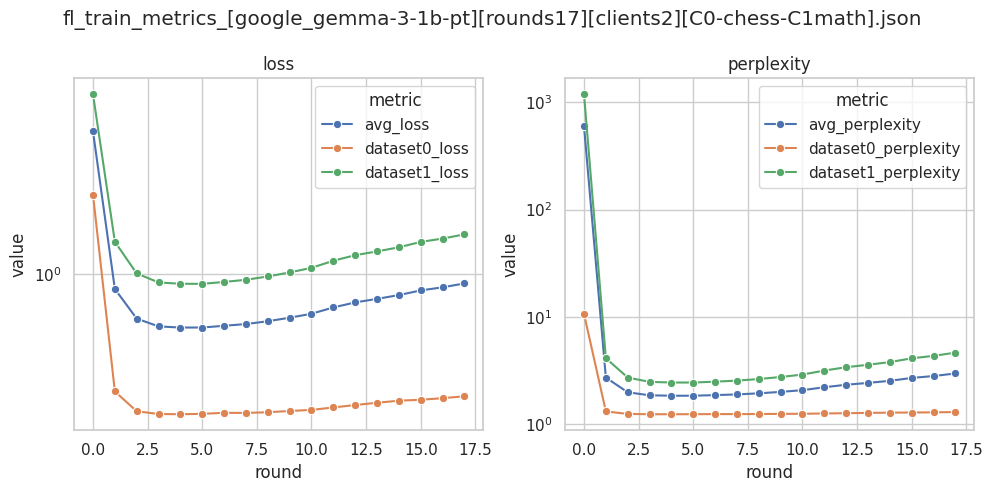

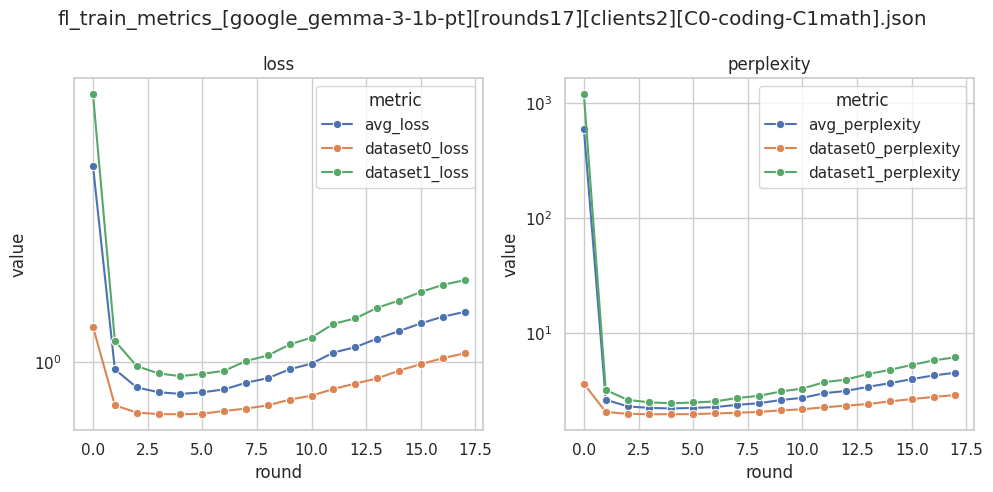

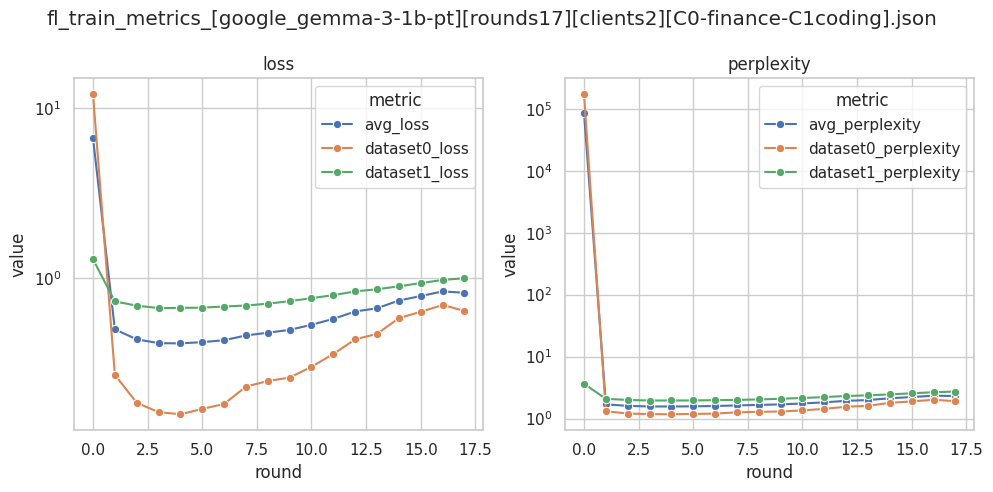

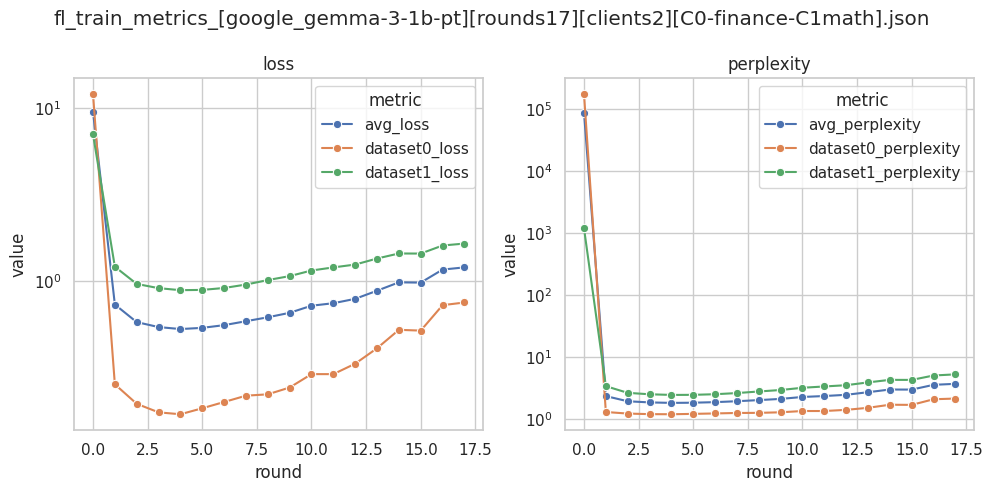

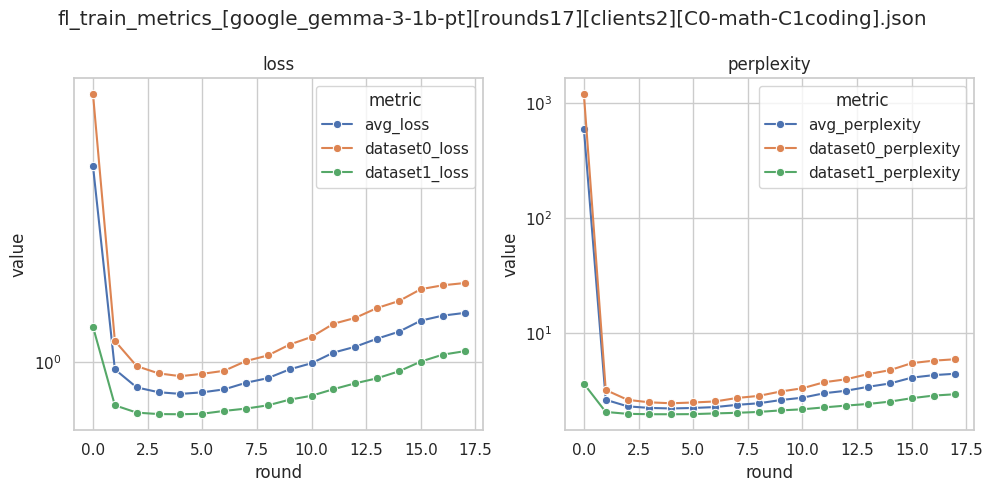

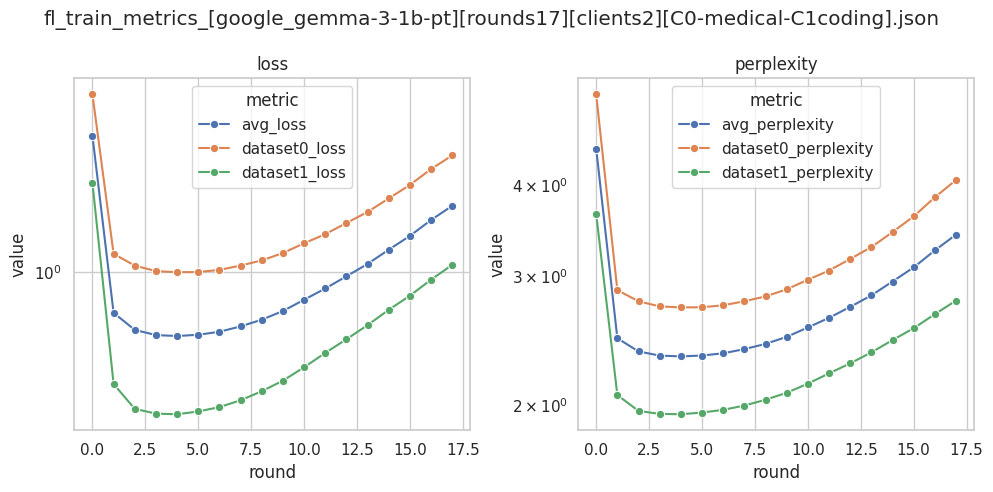

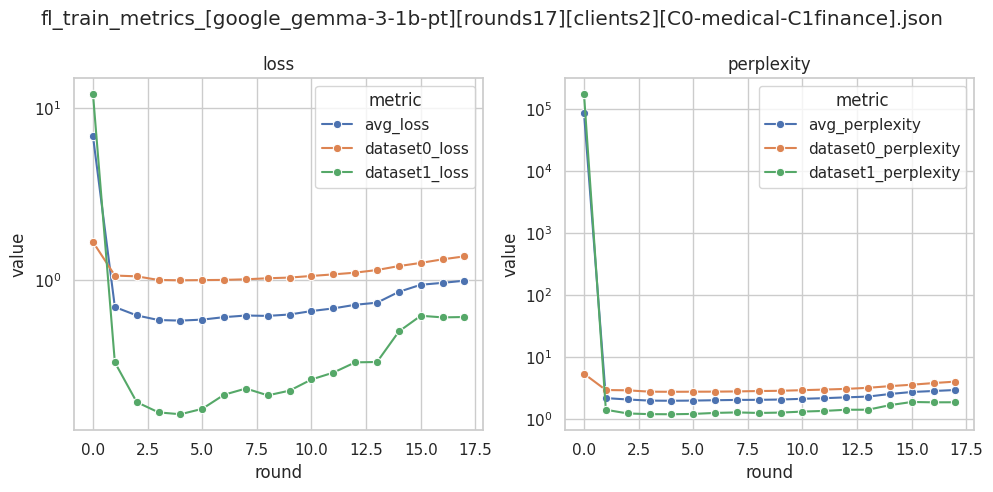

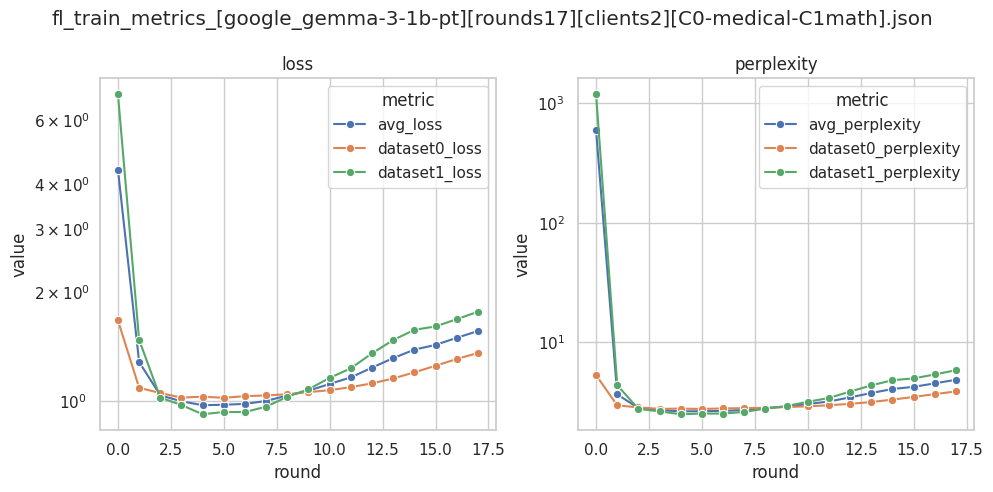

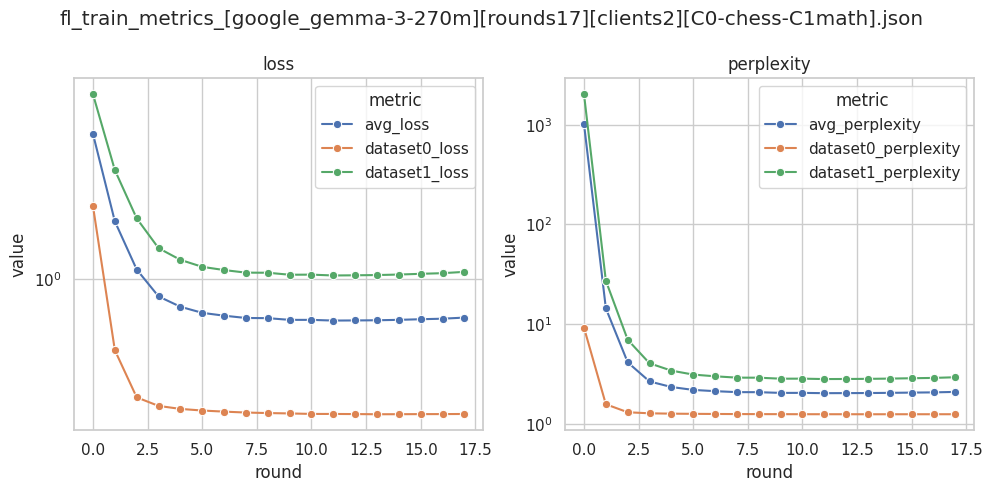

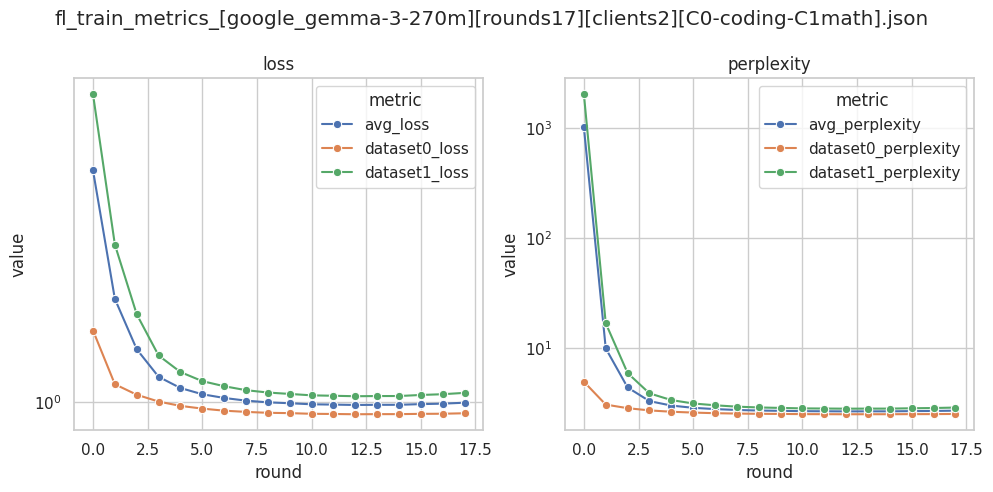

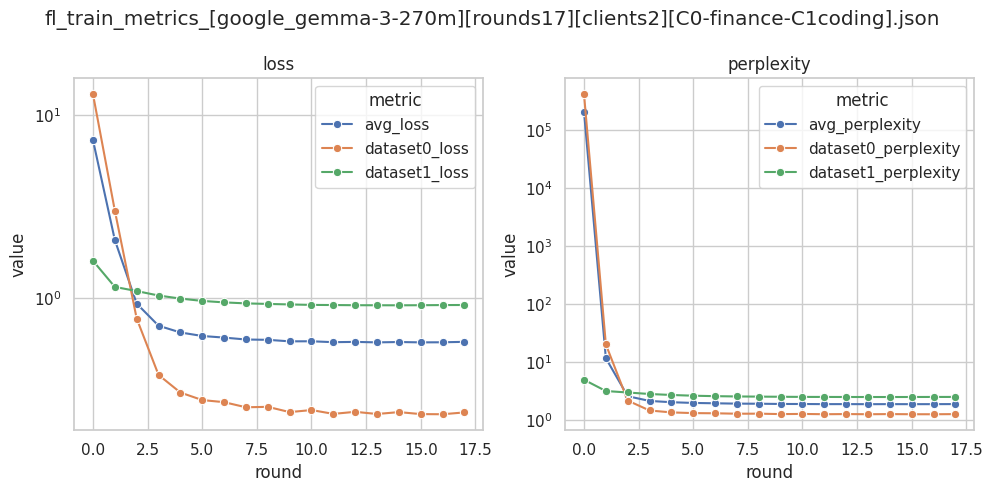

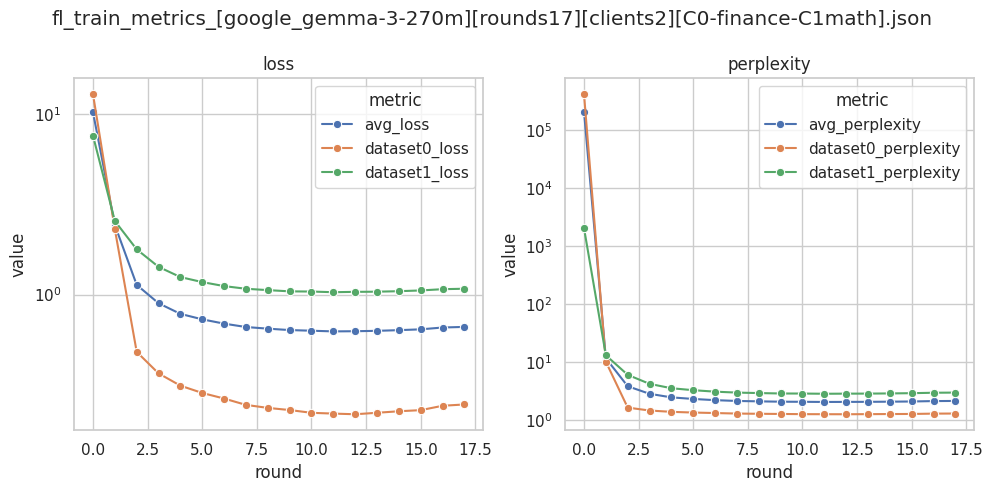

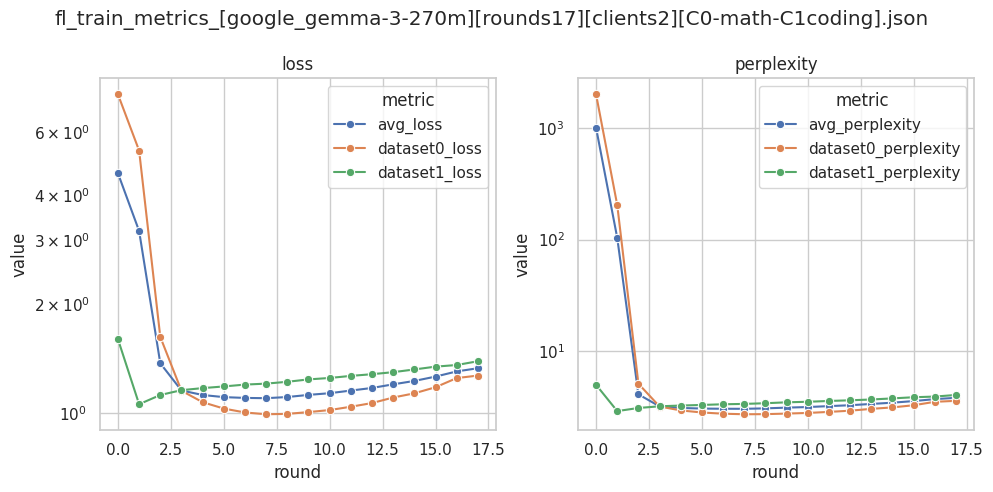

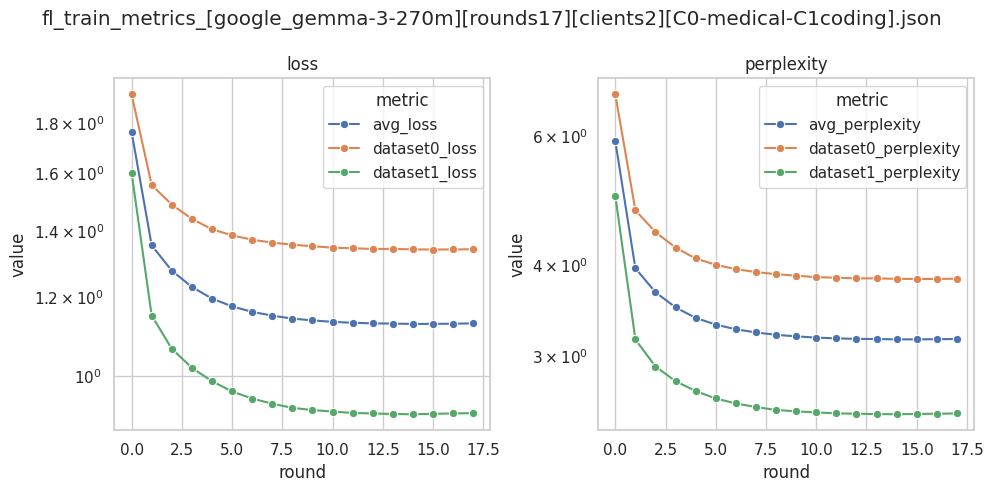

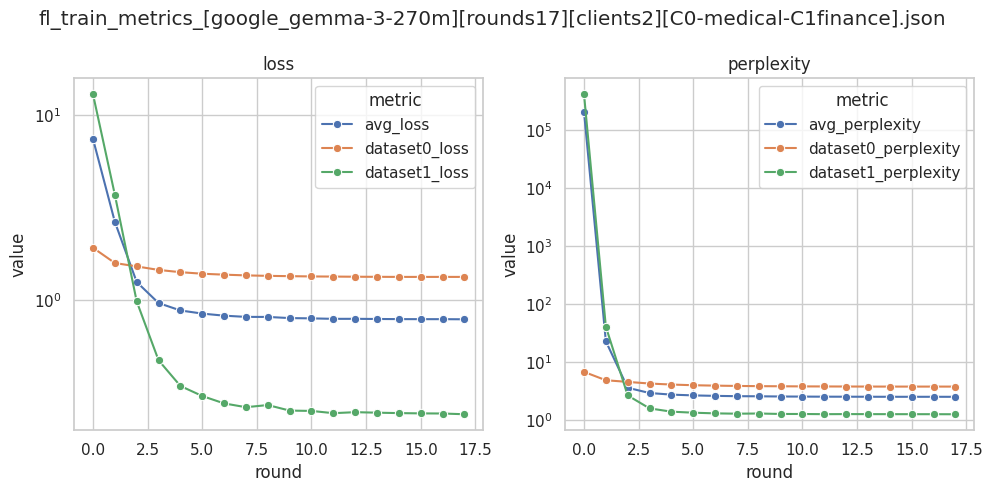

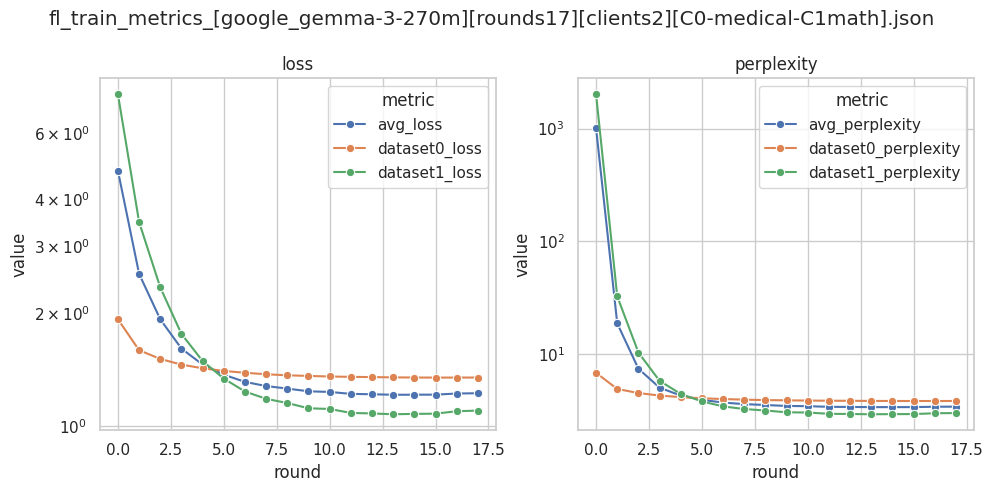

In [2]:
for f in sorted(Path("results").glob("fl_train_*.json")):
    if "LoRA" in f.name:
        continue
    plot_metrics(f)


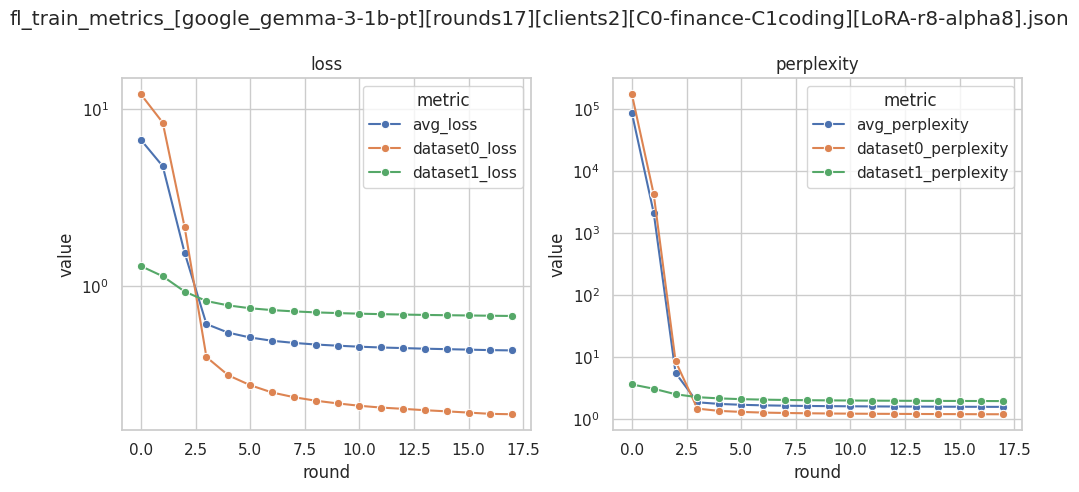

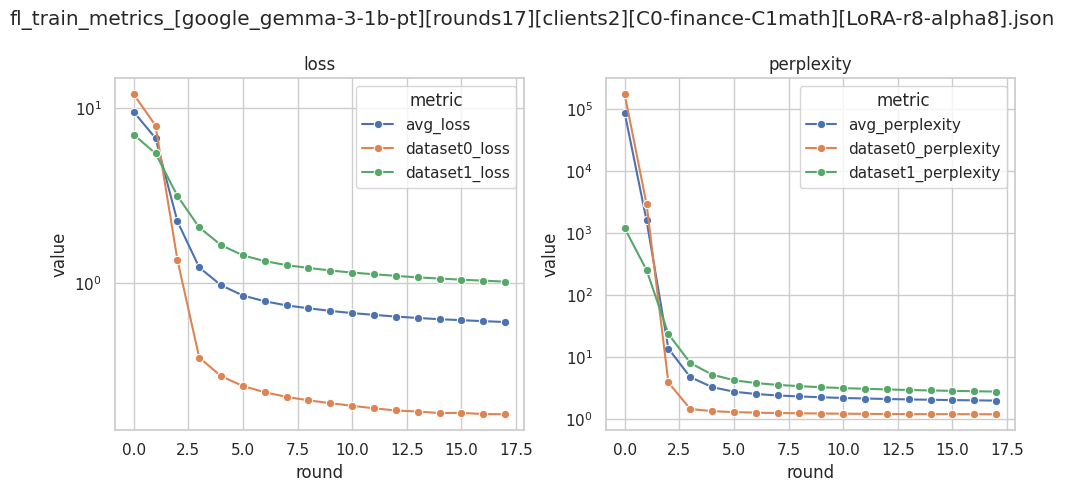

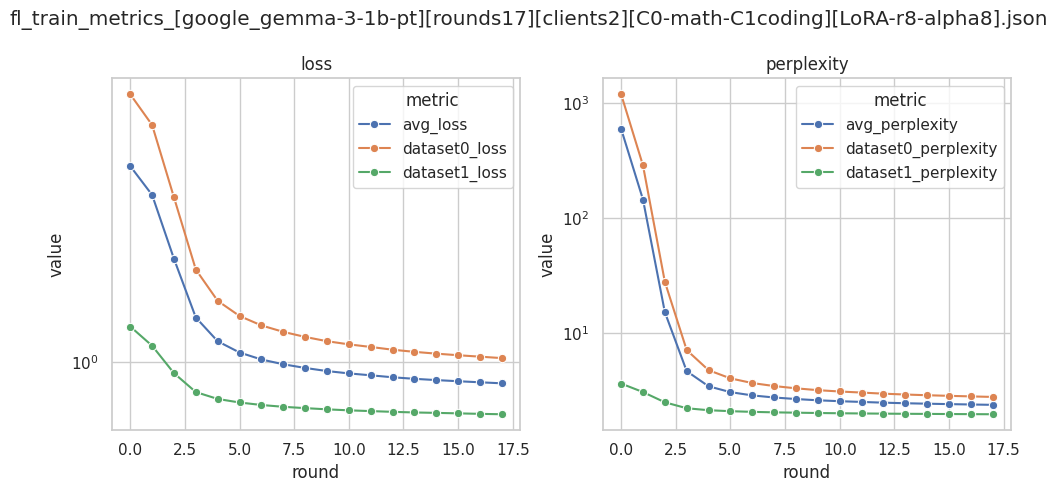

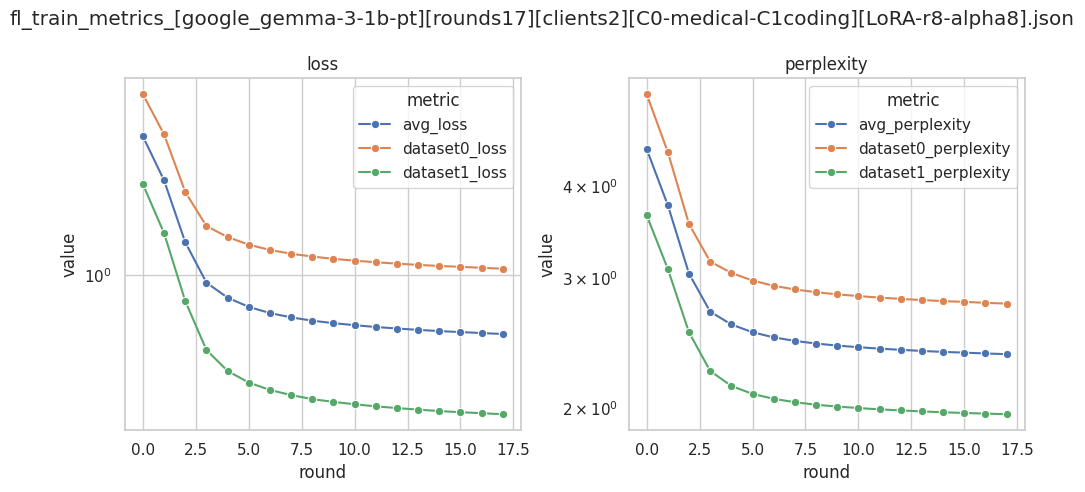

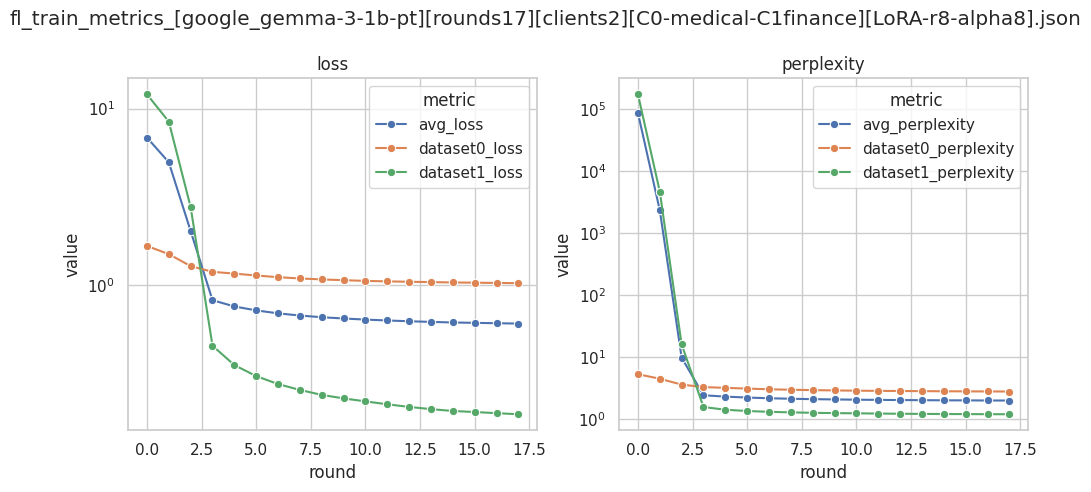

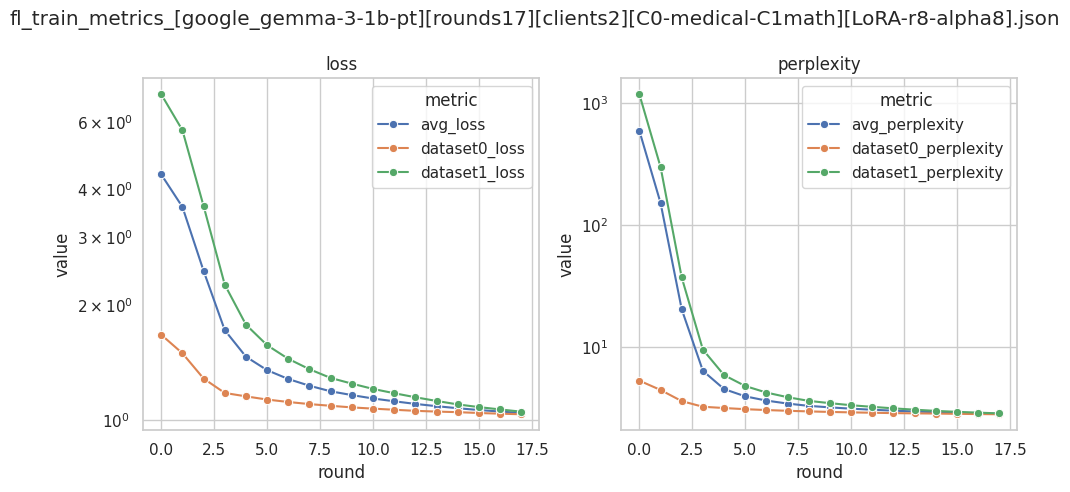

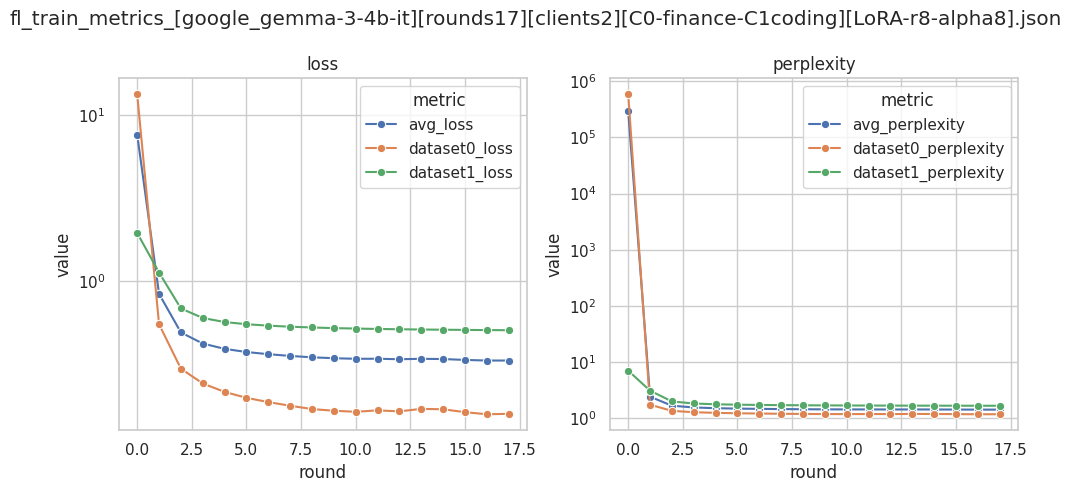

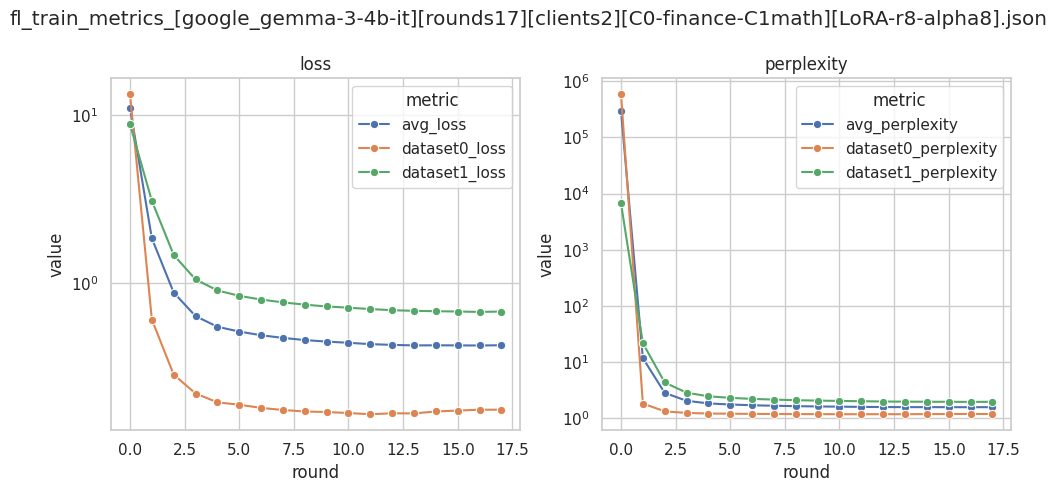

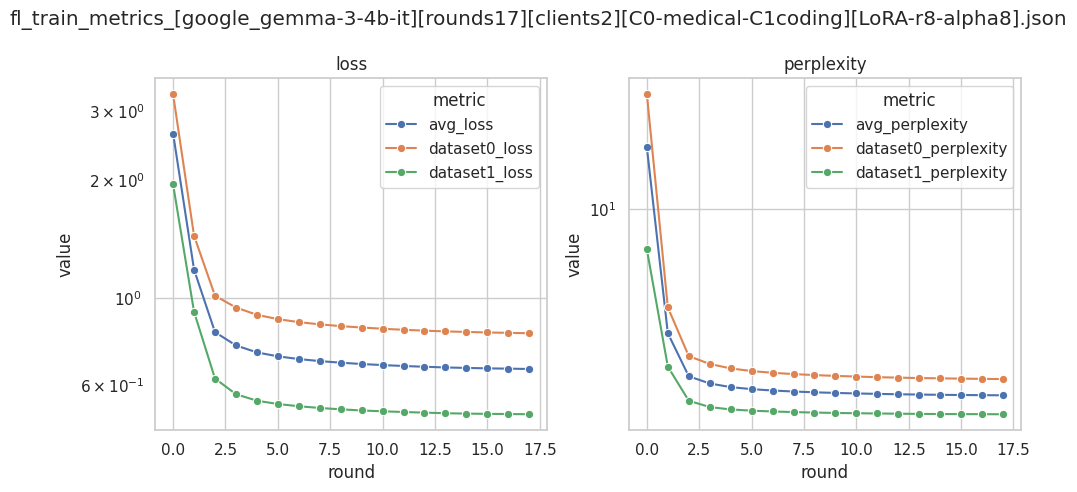

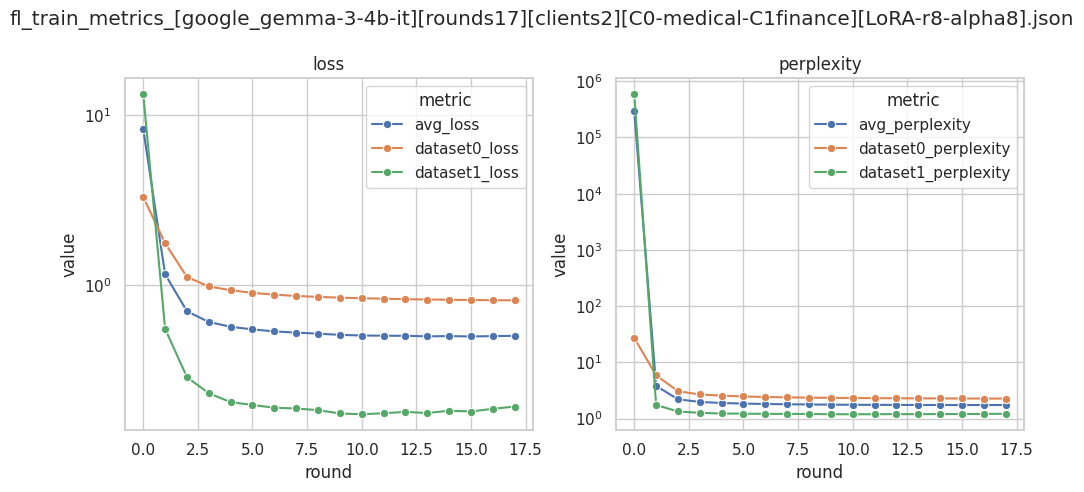

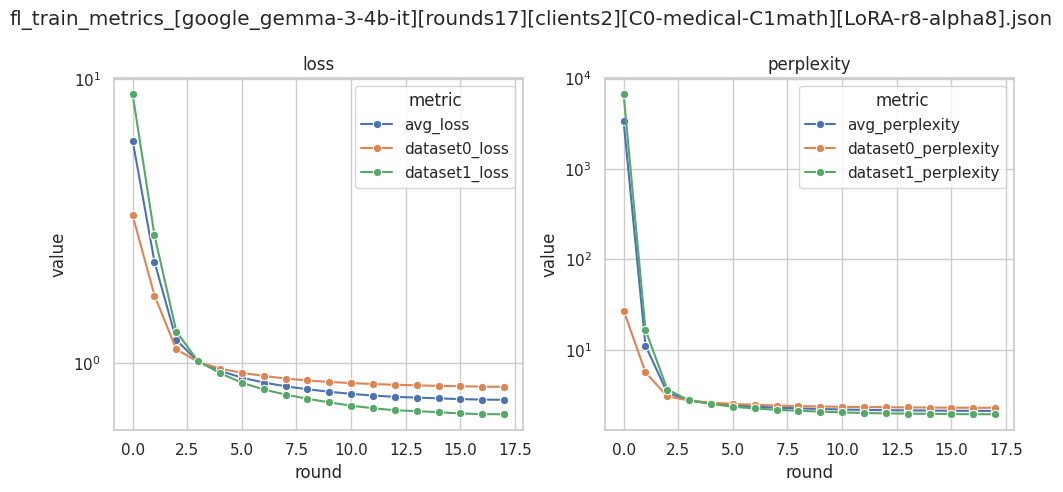

In [3]:
for f in sorted(Path("results").glob("fl_train_*.json")):
    if "LoRA" in f.name:
        plot_metrics(f)


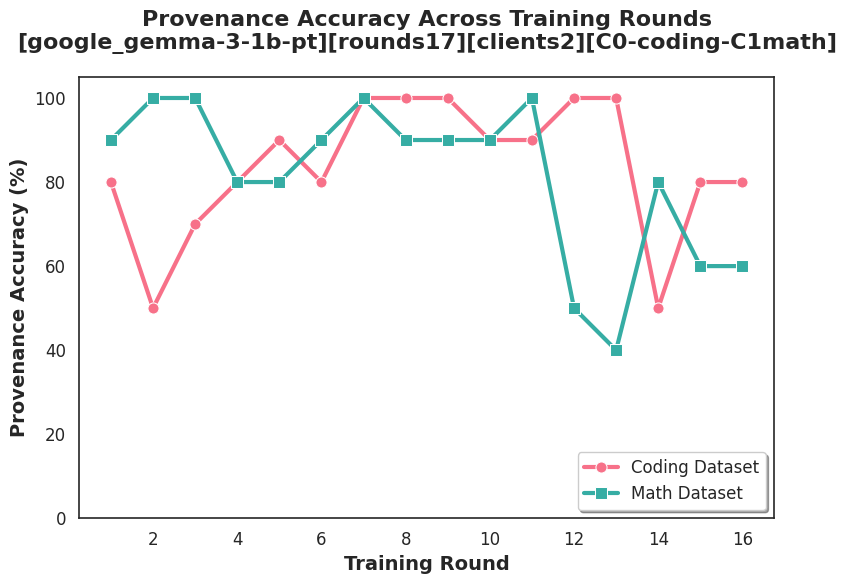

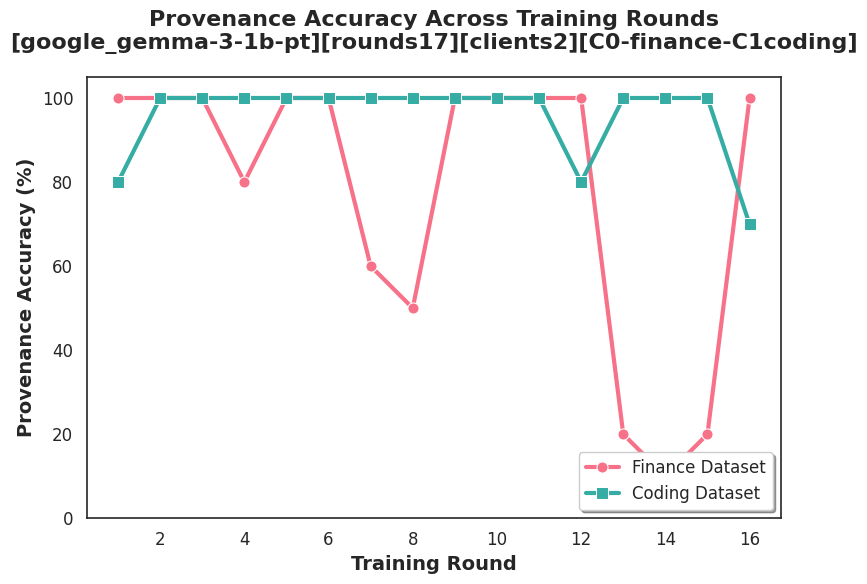

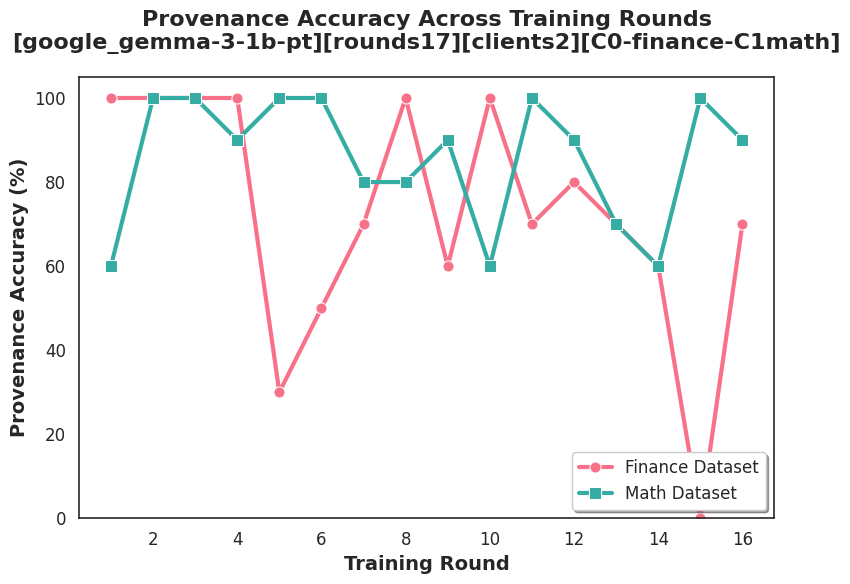

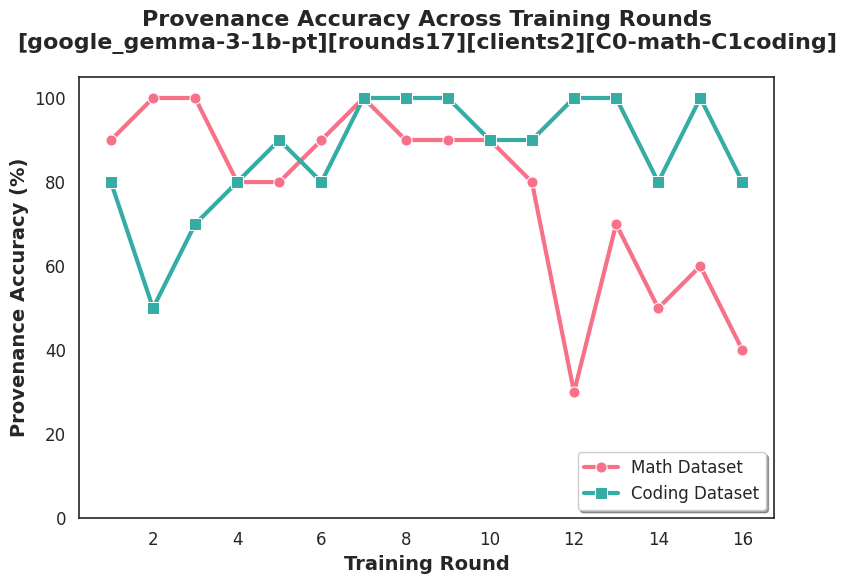

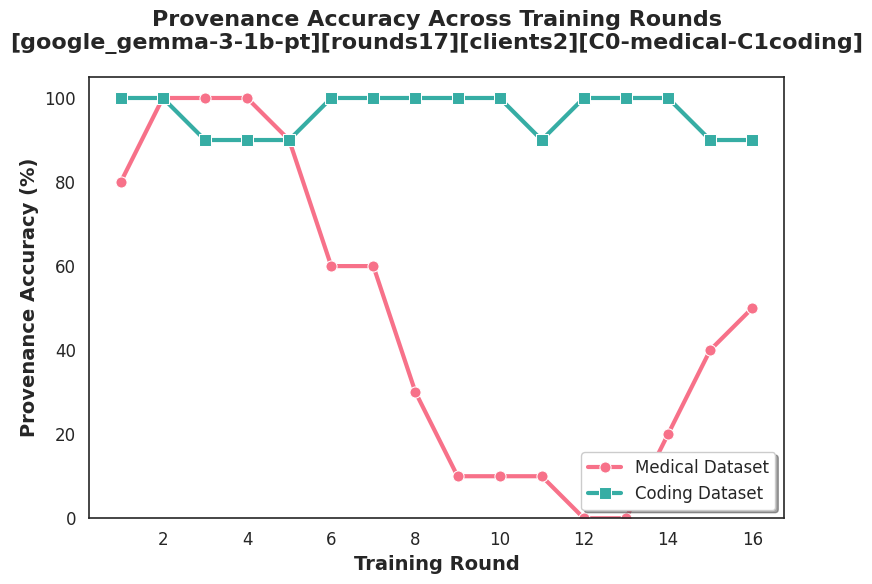

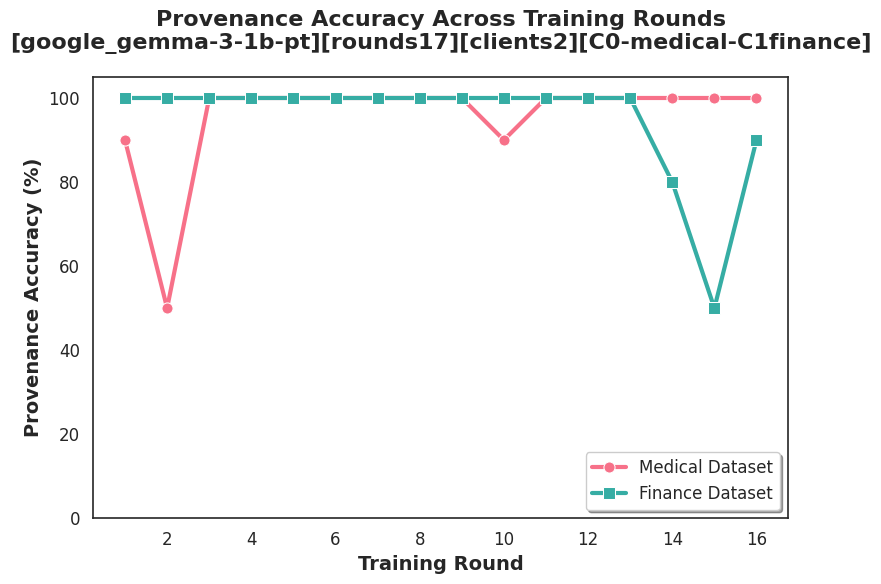

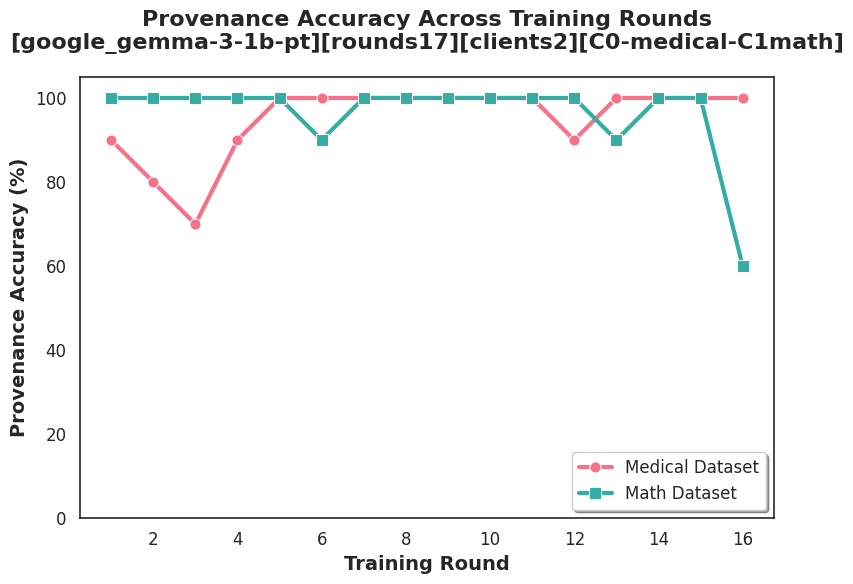

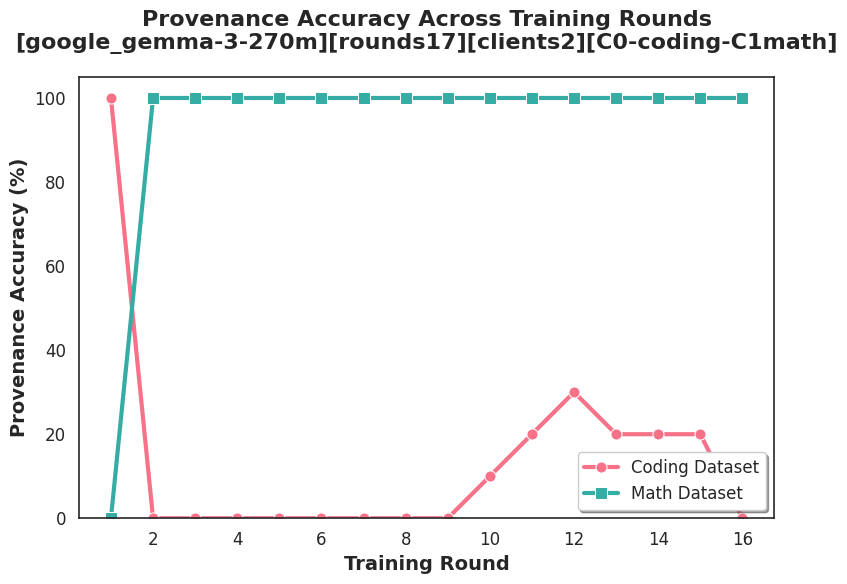

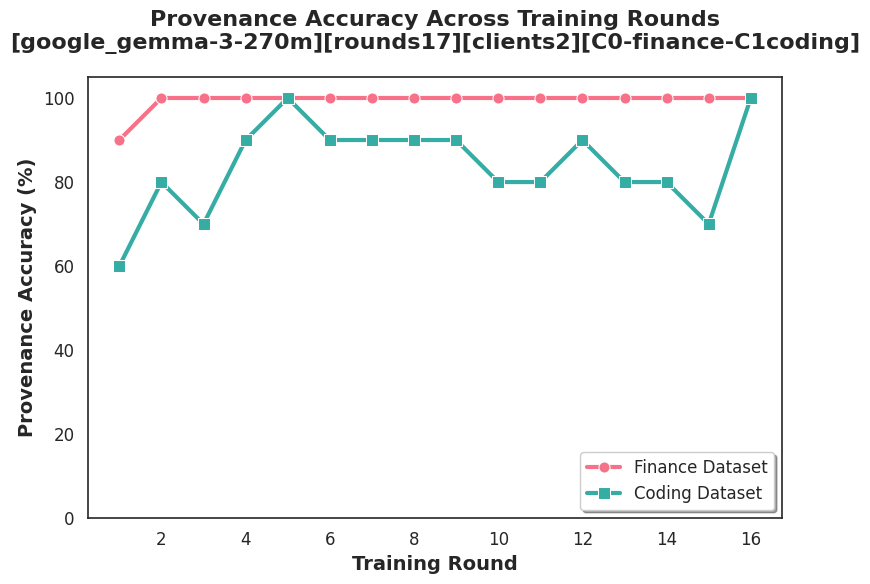

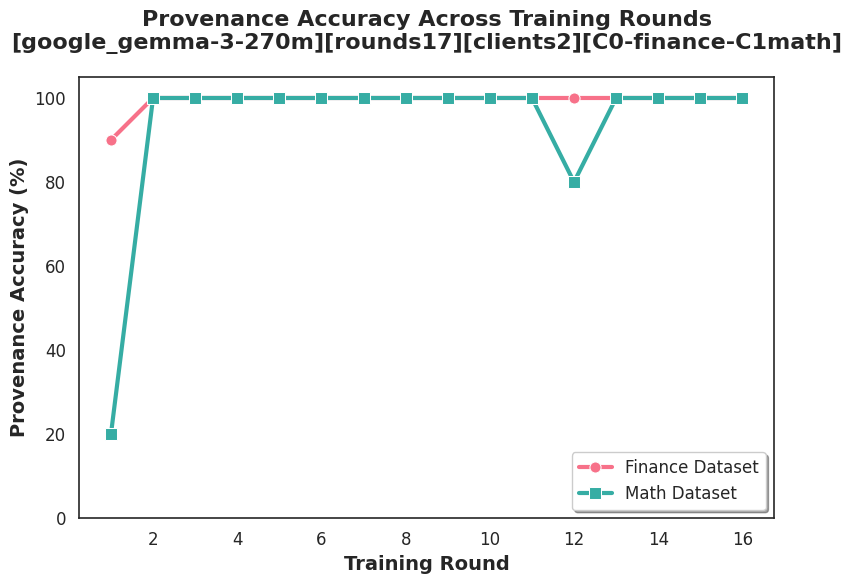

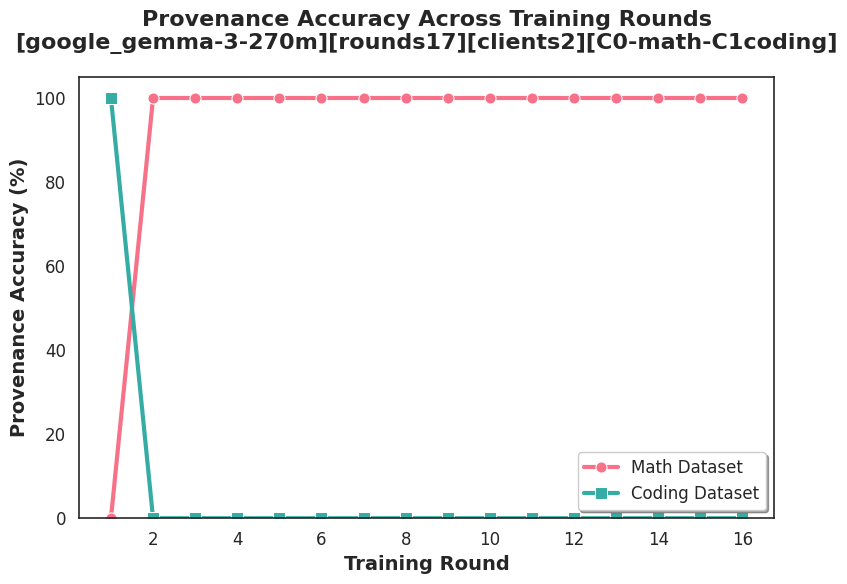

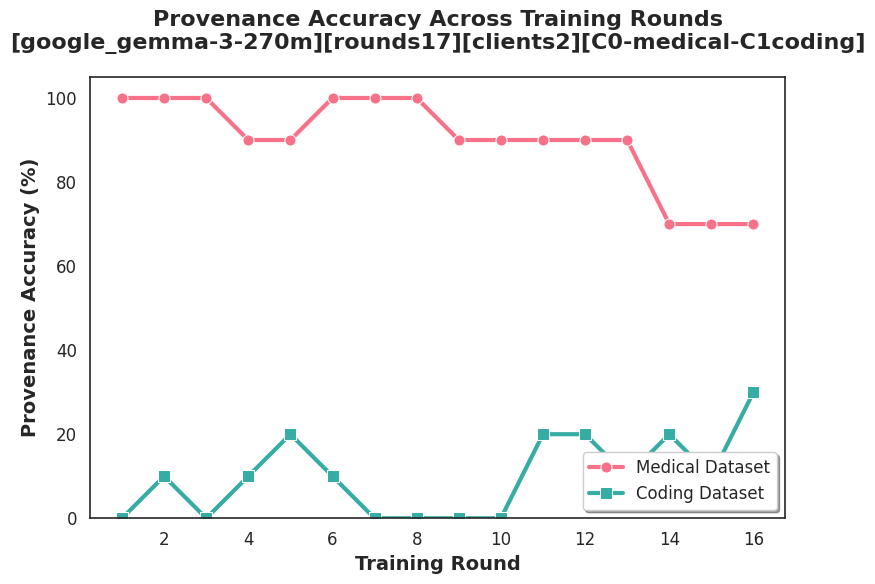

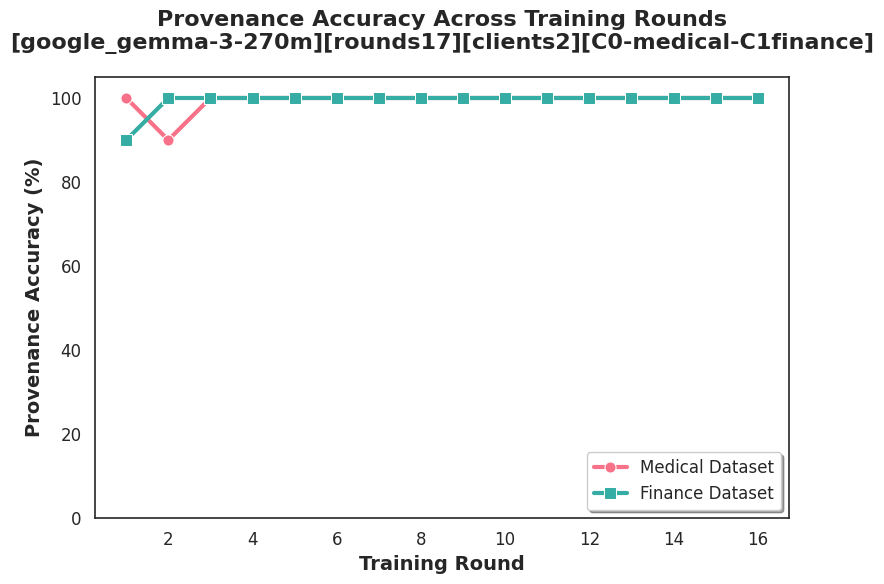

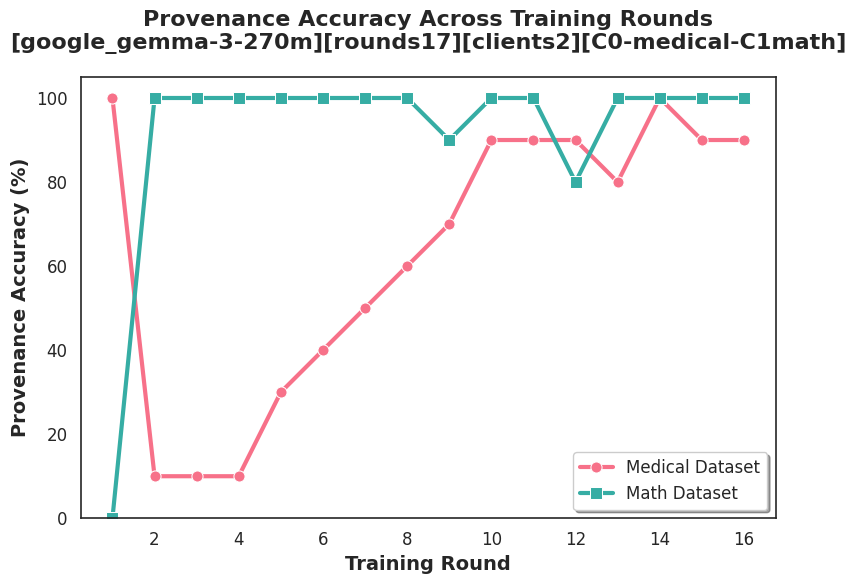

In [4]:
for f in sorted(Path("results").glob("*_provenance.json")):
    if "LoRA" in f.name:
        continue
    plot_provenance_accuracy(f, results_dir=None)
